# Quality Control of AFM Force Spectroscopy Data with Conditional Variational Autoencoders


<a href="https://colab.research.google.com/github/JChonpca/ASAP/blob/CVAE/tutorial/QC/QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook provides you with a complete code example that first trains a conditional variational autoencoder on AFM force spectroscopy curves in a self-supervised way; then constructs a latent space where the AFM curves are placed; and finally uses the latent space to check the quality of the AFM curves.


In [25]:
# Uncomment codes in this cell if using Colab/Kaggle.

# !pip install deeplay ipympl   
# from google.colab import output
# output.enable_custom_widget_manager()

## 1. Load the 3T3 Cell Dataset

### 1.1. Download the 3T3 Cell Dataset

Download the 3T3_cell_dataset into the `3T3_cell_dataset` local folder.

This dataset contains AFM force spectroscopy collected using a culture of 3T3 cells (a widely used, immortalized mouse fibroblast cell line derived from Swiss albino mouse embryos).

This dataset contains
- `approach` is a folder with the approach curves, as files `0.npy`, `1.npy`, etc.
- `retraction` is a folder with the retraction curves, paired with the approach curves.
- `label.npy` is the label file for the approach curves: `0` is for good curves, `1` is for bad curves, and `-1` is for curves of unknown quality.
- `contact_point.npy` contains the contact points for each curve.

In [26]:
import os

if not os.path.exists("3t3_cell_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/3t3_cell_dataset")

### 1.2. Explore the 3T3 Cell Dataset

Load the 3T3 cell dataset ...

In [27]:
from pathlib import Path
import numpy as np

# Load the approach curves
approach_path = Path.cwd() / "3t3_cell_dataset" / "approach"
approach_files = sorted(approach_path.glob("*.npy"), key=lambda f: int(f.stem))
approach_curves = [np.load(f) for f in approach_files]

# Load the retraction curves
retract_path = Path.cwd() / "3t3_cell_dataset" / "retraction"
retract_files = sorted(retract_path.glob("*.npy"), key=lambda f: int(f.stem))
retract_curves = [np.load(f) for f in retract_files]

# Load the labels
labels = np.load(Path.cwd() / "3t3_cell_dataset" / "label.npy")

# Load the contact points
contactpoints = np.load(Path.cwd() / "3t3_cell_dataset" / "contact_point.npy")

... print the number of approach/retraction curves and labels ...

In [28]:
print(
    f"3T3 cell dataset:\n"
    f"- {len(approach_curves)} approach curves\n"
    f"- {len(retract_curves)} retraction curves\n"
    f"- {len(labels)} labels\n"
    f"- {len(contactpoints)} contact points"
)

3T3 cell dataset:
- 2548 approach curves
- 2548 retraction curves
- 2548 labels
- 2548 contact points


... calculate the length of each curve in the dataset ...

In [29]:
# Calculate the length of each curve
approach_curve_lengths = [curve.shape[0] for curve in approach_curves]
retract_curve_lengths = [curve.shape[0] for curve in retract_curves]

# Calculate the minimum length of approach curves and retraction curves
min_approach_curve_length = min(approach_curve_lengths)
min_retract_curve_length = min(retract_curve_lengths)

print(
    f"Minimum approach curve length = {min_approach_curve_length}\n"
    f"Minimum retraction curve length = {min_retract_curve_length}\n"
)

Minimum approach curve length = 1557
Minimum retraction curve length = 3000



... and visualize the distribution (the lengths of the approach curves are usually shorter than the value set in the experiments, 3000, due to differences in topology across the cells).

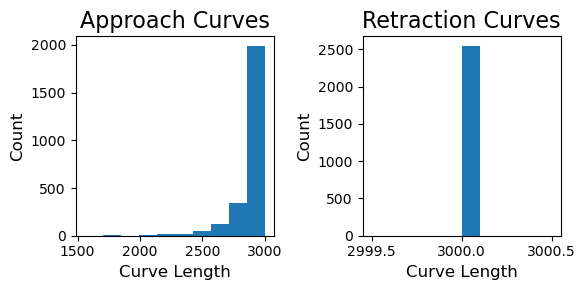

In [30]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=((6, 3)))

# Plot the length distribution of the approach curves
axs[0].hist(approach_curve_lengths)
axs[0].set_title("Approach Curves", fontsize=16)
axs[0].set_xlabel("Curve Length", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)

# Plot the length distribution of the retraction curves
axs[1].hist(retract_curve_lengths)
axs[1].set_title("Retraction Curves", fontsize=16)
axs[1].set_xlabel("Curve Length", fontsize=12)
axs[1].set_ylabel("Count", fontsize=12)
axs[1].ticklabel_format(axis="x", useOffset=False)

fig.tight_layout()
plt.show()

Finally, you can plot some paired approach/retraction curves, highlighting the the contact point.

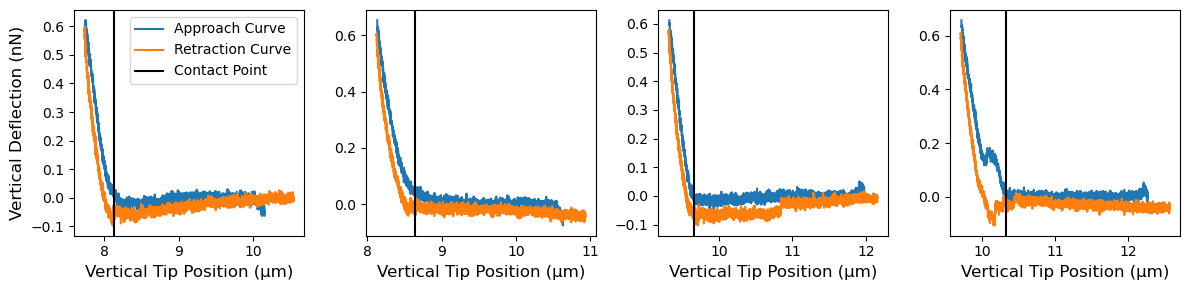

In [31]:
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))

for curve_idx, ax in enumerate(axs.ravel()):
    approach_curve = approach_curves[curve_idx]
    retract_curve = retract_curves[curve_idx]
    contactpoint = contactpoints[curve_idx]

    ax.plot(approach_curve[:, 0], approach_curve[:, 1], label="Approach Curve")

    ax.plot(retract_curve[:, 0], retract_curve[:, 1], label="Retraction Curve")

    ax.axvline(contactpoint, c="k", label="Contact Point")

    ax.set_xlabel("Vertical Tip Position (µm)", fontsize=12)
    if curve_idx == 0:
        ax.set_ylabel("Vertical Deflection (nN)", fontsize=12)
        ax.legend()

fig.tight_layout()
plt.show()

## 2. Quality Control of Approach Curves

### 2.1. Data Preprocessing

For the approach curves, resample each approach curve to adjust its length align with the shortest approach curve ...

In [32]:
resampled_approach_curves = []
resampled_contactpoints = []
for approach_curve, contactpoint in zip(approach_curves, contactpoints):
    # Resample each approach curve to adjust its length to the shortest one
    steps = np.round(                                                          # TODO: Would interpolation be better than downsampling? Please, try and let me know.
        np.linspace(0, approach_curve.shape[0] - 1, min_approach_curve_length) # TODO: Try also to downsample the approach curve to, for example, 100 points and see if this improves the result.
    ).astype(int)
    resampled_approach_curve = approach_curve[steps][:, 1]
    resampled_approach_curves.append(resampled_approach_curve)

    # Determine the contact point for the resampled approach curve
    resampled_approach_position = approach_curve[steps][:, 0]
    resampled_contactpoint = (
        np.abs(resampled_approach_position - contactpoint).argmin()
    )
    resampled_contactpoints.append(resampled_contactpoint)

... and normalize each approach curve betweeen 0 and 1.

In [33]:
# Normalize each approach curve according to its max and min values
norm_approach_curves = []

for resampled_approach_curve in resampled_approach_curves:
    norm_approach_curves.append(
        (resampled_approach_curve - resampled_approach_curve.min())
        / (resampled_approach_curve.max() - resampled_approach_curve.min())
    )

# Normalize each contact point according to min approach length
norm_contact_points = []

for resampled_contactpoint in resampled_contactpoints:
    norm_contact_points.append(
        resampled_contactpoint / min_approach_curve_length
    )

Finally, you can plot some normalized curves.

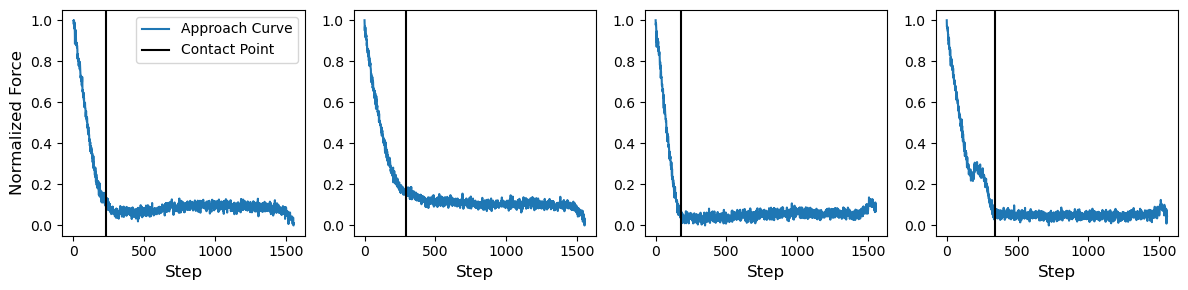

In [34]:
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))

for curve_idx, ax in enumerate(axs.ravel()):
    norm_approach_curve = norm_approach_curves[curve_idx][::-1]
    resampled_contactpoint = (
        min_approach_curve_length - resampled_contactpoints[curve_idx]
    )

    ax.plot(norm_approach_curve, label="Approach Curve")

    ax.axvline(resampled_contactpoint, c="k", label="Contact Point")

    ax.set_xlabel("Step", fontsize=12)
    if curve_idx == 0:
        ax.set_ylabel("Normalized Force", fontsize=12)
        ax.legend()

fig.tight_layout()
plt.show()

### 2.2. Define the Dataloader

Define a custom AFM dataset ...

In [35]:
import torch

class AFMDataset(torch.utils.data.Dataset):
    """Dataset for AFM Force Spectroscopy.

    This dataset is designed for handling Atomic Force Microscopy (AFM)
    force spectroscopy curves along with their corresponding contact points.
    Each sample consists of a force curve and an associated condition value
    (contact point), which can be used in conditional models such as CVAE.

    The dataset returns the input curve, target curve (same as input for
    reconstruction tasks), and the contact point.

    Parameters
    ----------
    curves : array-like
        Collection of AFM curves. Shape: (num_samples, curve_length).
    contactpoints : array-like
        Corresponding contact points for each curve. Shape: (num_samples, ...).

    Attributes
    ----------
    curves : np.ndarray
        Stored AFM curves.
    contactpoints : np.ndarray
        Stored contact point values.

    Input
    -----
    idx : int
        Index of the sample to retrieve.

    Output
    ------
    list
        [curve, target, condition], where:
        - curve : torch.Tensor
            Input curve.
        - target : torch.Tensor
            Target curve (same as input).
        - condition : torch.Tensor
            Contact point (conditioning variable).

    Examples
    --------
    >>> curves, contactpoints = torch.randn(10, 100), torch.rand(10, )
    >>> dataset = AFMDataset(curves, contactpoints)
    >>> curve, target, c = dataset[0]
    >>> curve.shape, target.shape, c.shape
    (torch.Size([100]), torch.Size([100]), torch.Size([]))
    >>> len(dataset)
    10
    """

    def __init__(self, curves, contactpoints):
        """Initializes the AFM dataset.

        Parameters
        ----------
        curves : array-like
            Collection of AFM curves.
        contactpoints : array-like
            Corresponding contact points.
        """
        
        self.curves = np.array(curves)
        self.contactpoints = np.array(contactpoints)

    def __len__(self):
        """Returns the total number of samples in the dataset.

        Returns
        -------
        int
            Number of curves in the dataset.
        """
        
        return self.curves.shape[0]

    def __getitem__(self, idx):
        """Retrieves a single sample from the dataset.

        This method returns the curve, its corresponding target (same as
        the input curve for reconstruction tasks), and the associated
        contact point.

        Parameters
        ----------
        idx : int
            Index of the sample.

        Returns
        -------
        list
            [curve, target, condition], where each element is a torch.Tensor.
        """
        
        curve = torch.tensor(self.curves[idx]).float()
        contactpoint = torch.tensor(self.contactpoints[idx]).float()
        return [curve, curve, contactpoint]

... and use it to create the train and test data loaders.

In [36]:
import deeplay as dl
from sklearn.model_selection import train_test_split

# Randomly select the train and test data
(
    curves_train, curves_test,
    labels_train, labels_test,
    contactpoints_train, contactpoints_test,
) = train_test_split(
    norm_approach_curves,
    labels,
    norm_contact_points,
    test_size=0.2,
    random_state=577,
)

# Instantiate the dataloader for train data
train_dataloader = dl.DataLoader(
    AFMDataset(curves=curves_train, contactpoints=contactpoints_train),
    batch_size=len(curves_train),
)

# Instantiate the dataloader for test data
test_dataloader = dl.DataLoader(
    AFMDataset(curves=curves_test, contactpoints=contactpoints_test),
    batch_size=len(curves_test),
)

### 2.3. Define the Autoencoder

Import and instantiate a conditional variational autoencoder (CVAE) with dense layers.

In [37]:
from cvae import ConditionalVariationalAutoEncoder

# Instantiate the CVAE model according to the data properties
cvae = ConditionalVariationalAutoEncoder(
    input_size=min_approach_curve_length,
    condition_dim=1,
    channels=[512, 256, 128, 64],
    reconstruction_loss=torch.nn.MSELoss(reduction="sum"),
    beta=1,
    latent_dim=2,
)

# Configure the activated function
cvae.encoder.blocks[:].activated(torch.nn.Tanh)
cvae.decoder.blocks[:4].activated(torch.nn.Tanh)
cvae.decoder.blocks[4].activated(torch.nn.Sigmoid)

# Create the CAVE application
cvae = cvae.create()

print(cvae)

ConditionalVariationalAutoEncoder(
  (encoder): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=1558, out_features=512, bias=True)
        (activation): Tanh()
      )
      (1): LinearBlock(
        (layer): Linear(in_features=512, out_features=256, bias=True)
        (activation): Tanh()
      )
      (2): LinearBlock(
        (layer): Linear(in_features=256, out_features=128, bias=True)
        (activation): Tanh()
      )
      (3): LinearBlock(
        (layer): Linear(in_features=128, out_features=64, bias=True)
        (activation): Tanh()
      )
      (4): LinearBlock(
        (layer): Linear(in_features=64, out_features=64, bias=True)
        (activation): Tanh()
      )
    )
  )
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_var): Linear(in_features=64, out_features=2, bias=True)
  (fc_dec): Linear(in_features=3, out_features=64, bias=True)
  (decoder): MultiLayerPerceptron(
    (blocks): LayerLis

### 2.4. Train the Autoencoder

Instance a trainer with a callback to monitor the validation loss and save the best model ...

In [38]:
from lightning.pytorch.callbacks import ModelCheckpoint

# Save the top-1 model according to the validation loss
checkpoint_callback = ModelCheckpoint(
    monitor="val_total_loss",
    mode="min",
    save_top_k=1,
)

# Instantiate the trainer
vae_trainer = dl.Trainer(
    max_epochs=10_000,
    accelerator="auto",
    callbacks=[checkpoint_callback],
)

/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


... train the VAE ...

In [ ]:
vae_trainer.fit(cvae, train_dataloader, test_dataloader)

... and load the best model from the callback function.

In [ ]:
print(f"The best model is saved at {checkpoint_callback.best_model_path}")

best_cvae = ConditionalVariationalAutoEncoder.load_from_checkpoint(
    checkpoint_callback.best_model_path
)

You can also load a pretrained model by uncommenting the code below.

In [39]:
# Uncomment if you want to load a pretrained model

pretraiend_model_path = Path.cwd() / "models" / "epoch=6886-step=6887.ckpt"

print(f"Loading the model at {pretraiend_model_path}")

cvae.load_state_dict(
    torch.load(pretraiend_model_path, map_location="cpu")["state_dict"]
)
best_cvae = cvae

Loading the model at /Users/iluvatar/Desktop/Bruker_QC/personalrepo/ASAP/tutorial/QC/models/epoch=6886-step=6887.ckpt


### 2.5. Evaluate the Trained VAE

Evaluate the trained VAE using both the train dataset ...

In [41]:
# Evaluate performance of trained VAE on train dataset

_ = vae_trainer.test(best_cvae, train_dataloader)

Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_KL_epoch       │     271.2106018066406     │
│    test_rec_loss_epoch    │     2246.874755859375     │
│   test_total_loss_epoch   │     2518.085693359375     │
└───────────────────────────┴───────────────────────────┘

... and on the test dataset.

In [42]:
# Evaluate performance of trained VAE on test dataset

_ = vae_trainer.test(best_cvae, test_dataloader)

Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_KL_epoch       │     56.41820526123047     │
│    test_rec_loss_epoch    │     681.2374877929688     │
│   test_total_loss_epoch   │     737.6557006835938     │
└───────────────────────────┴───────────────────────────┘

### 2.6. Reconstruct and Denoise the Approach Curves

The trained VAE can used to reconstruct and denoise the approach curves.

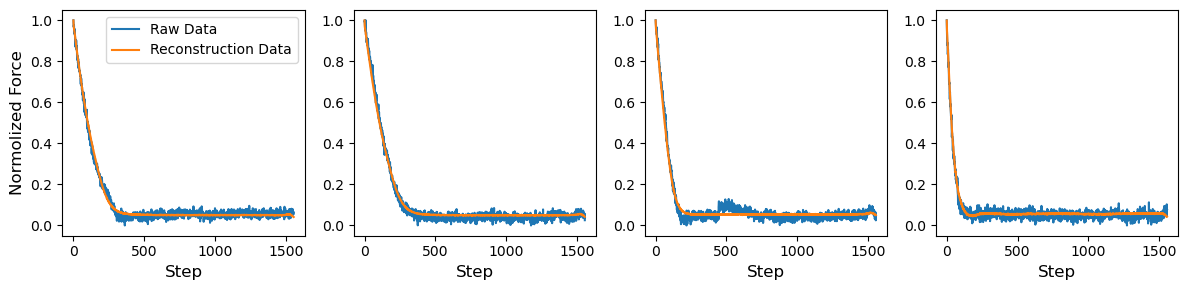

In [43]:
# Put the model under eval mode
best_cvae.eval()

# Collect the decoding curves and encoding latent space in the test dataset
with torch.no_grad():
    for indx, batch in enumerate(test_dataloader):
        x, y_list, c = batch
        y_hat_list, _, _, _ = best_cvae(x,c)


# Plot the comparison between the reconstruction and the originals
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))

for curve_idx, ax in enumerate(axs.ravel()):
    data_apporach_plot_raw = y_list[curve_idx].numpy()[::-1]
    data_apporach_plot_reconstruct = y_hat_list[curve_idx].numpy()[::-1]
    
    ax.plot(data_apporach_plot_raw, label="Raw Data")
    
    ax.plot(data_apporach_plot_reconstruct, label="Reconstruction Data")
    
    ax.set_xlabel("Step", fontsize=12)
    if curve_idx == 0:
        ax.set_ylabel("Normolized Force", fontsize=12)
        ax.legend()

fig.tight_layout()
plt.show()

### 2.7. Visualize the Latent Space 

Collect the decoding curves and encoding latent space in all curves ...

In [44]:
# Construct the
all_dataloader = dl.DataLoader(
    AFMDataset(curves=norm_approach_curves, contactpoints=norm_contact_points),
    batch_size=len(norm_approach_curves),
    shuffle=False
)

# collect the decoding curves and encoding latent space in the full dataset
with torch.no_grad():
    for indx, batch in enumerate(all_dataloader):
        x_list, _, c = batch
        _, mu_list, log_var_list, _ = best_cvae(x_list,c)

# Transfer them into Numpy array
x_list = x_list.numpy()
mu_list = mu_list.numpy()
log_var_list = log_var_list.numpy()

... and check the good/bad curves in the latent space with the provided label ...

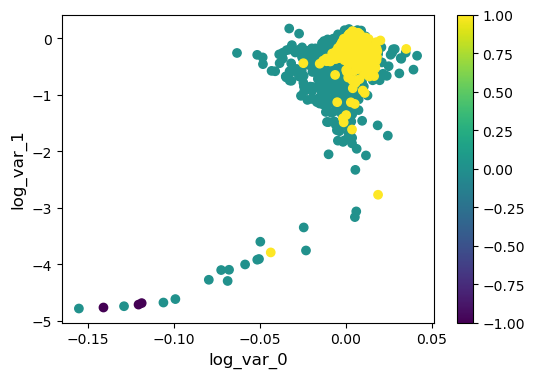

In [45]:
# Plot the latent space with labels
plt.figure(figsize=(6, 4))
plt.scatter(log_var_list[:,0],log_var_list[:,1], c=labels)
plt.xlabel("log_var_0", fontsize=12)
plt.ylabel("log_var_1", fontsize=12)
plt.colorbar()
plt.show()

... and play with weight.

In [46]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# Extract 2D latent variables (e.g., log-variance dimensions for visualization)
x = log_var_list[:, 0]
y = log_var_list[:, 1]

# Curves corresponding to each latent point
curves = x_list

# X-axis for plotting curves
x_curve = np.linspace(0, curves.shape[1], curves.shape[1])

# Define colors for different classes
colors = ["red", "green", "orange"]
marker_colors = [colors[c] for c in labels]

# Create subplot layout: left = embedding space, right = curve visualization
fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Embedding Space", "Corresponding Curve")
)

# Scatter plot of latent space points
scatter = go.Scatter(
    x=x,
    y=y,
    mode="markers",
    marker=dict(size=10, color=marker_colors),
    name="points",
)
fig.add_trace(scatter, row=1, col=1)

# Line plot placeholder for selected curve
curve = go.Scatter(
    x=[],
    y=[],
    mode="lines",
    line=dict(color="red"),
    name="curve",
)
fig.add_trace(curve, row=1, col=2)

# Marker to highlight selected point in latent space
selected_marker = go.Scatter(
    x=[],
    y=[],
    mode="markers",
    marker=dict(size=10, symbol="x", color="black", line=dict(width=2)),
    name="selected",
)
fig.add_trace(selected_marker, row=1, col=1)

# Convert to interactive FigureWidget
fig_widget = go.FigureWidget(fig)
fig_widget.update_layout(width=900, height=400)


def update_curve(trace, points, selector):
    """
    Callback function triggered when a point in the embedding space is clicked.

    Parameters
    ----------
    trace : plotly trace
        The scatter plot trace that received the click.
    points : plotly.callbacks.Points
        Information about the clicked points.
    selector : plotly.callbacks.InputDeviceState
        Additional selection info (not used here).
    """
    if points.point_inds:
        idx = points.point_inds[0]  # index of selected point
        selected_color = marker_colors[idx]

        with fig_widget.batch_update():
            # Update curve plot with corresponding color
            fig_widget.data[1].x = x_curve
            fig_widget.data[1].y = curves[idx][::-1]
            fig_widget.data[1].line.color = selected_color
            fig_widget.layout.annotations[1].text = f"Curve {idx}"

            # Highlight selected point in embedding space
            fig_widget.data[2].x = [x[idx]]
            fig_widget.data[2].y = [y[idx]]


# Attach click callback to scatter plot
fig_widget.data[0].on_click(update_curve)

# Display interactive widget
display(fig_widget)

FigureWidget({
    'data': [{'marker': {'color': [red, red, red, ..., orange, orange, orange],
                         'size': 10},
              'mode': 'markers',
              'name': 'points',
              'type': 'scatter',
              'uid': 'a7a06958-507d-4b3a-8873-49df067fc5c9',
              'x': {'bdata': ('LqrcOhFN7Ds3OxS7G0UCvKKlObxORA' ... 'sOwRg8H81Lu4249r2zPhC+wfryvQ=='),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('cboyPXNVzT2r2Tu+nW0pvuKTcL8i+W' ... '66pki+0iB+vhLnlsCEj5jAihCWwA=='),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'line': {'color': 'red'},
              'mode': 'lines',
              'name': 'curve',
              'type': 'scatter',
              'uid': 'dbc63828-4d37-4852-a553-8b93fe086bc4',
              'x': [],
              'xaxis': 'x2',
              'y': [],
              'yaxis': 'y2'},
             {'marker': {'color': 'black', 'line': {'width': 2}, 'size': 1